# Comprendre les arbres de décision

Un **arbre de décision** est un des modèles de machine learning les plus intuitifs : il prend des décisions en **posant une suite de questions** simples de type *oui/non*, exactement comme dans un jeu de « Qui est-ce ? ».

> **L'idée en une image :** imaginez un médecin qui diagnostique un patient. Il demande :
> - *« Température > 38° ? »* Oui → il demande une autre question. Non → autre question.
> - *« Toux sèche ? »* Oui → ... Non → ...
> - Après quelques questions, il arrive à un diagnostic.
>
> Un arbre de décision fait *exactement* la même chose, mais les questions et leurs seuils sont **appris automatiquement** à partir des données.

Dans ce notebook on va :
1. Voir à quoi **ressemble concrètement** un arbre entraîné (sur le dataset Iris) ;
2. Comprendre **comment il fait ses prédictions** (classification et probabilités) ;
3. Découvrir **comment il apprend** (algorithme CART, indice de Gini) ;
4. Voir sa **variante pour la régression** (prédire un nombre au lieu d'une classe).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

## Le modèle construit par l'algorithme — Classification

On va entraîner un arbre de décision sur le **dataset Iris** (un classique) : il contient 150 fleurs d'iris appartenant à 3 espèces (*setosa*, *versicolor*, *virginica*), décrites par la longueur et la largeur de leurs pétales et sépales.

**Objectif :** à partir des mesures d'une fleur, prédire son espèce. C'est donc un problème de **classification** (la sortie est une catégorie, pas un nombre).

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
X = iris.data[:, 2:] # petal length and petal width
y = iris.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=3)

In [5]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=2)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=2)

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Structure de l'arbre

Une fois l'arbre entraîné, on peut le **visualiser** directement — c'est l'un des grands atouts de ce modèle. Chaque nœud correspond à une question posée sur une feature, et chaque feuille à une prédiction.

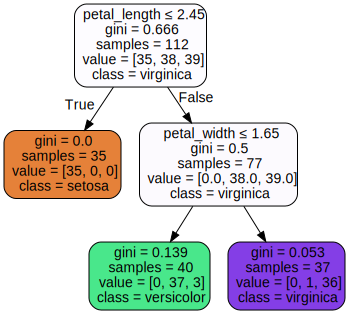

In [7]:
from sklearn.tree import export_graphviz
from graphviz import Source

dot_data = export_graphviz(tree_clf, out_file=None, 
                           feature_names=["petal_length", "petal_width"],  
                           class_names=iris.target_names,  
                           filled=True, rounded=True,  
                           special_characters=True)
Source(dot_data)

### Lire l'arbre

**Comment classer un iris ?** On démarre tout en haut (la racine, niveau 0) et on descend en répondant aux questions :

1. *« $\mathit{petal\_length} \le 2{,}35$ ? »*
   - **Oui** → on descend à gauche. C'est déjà une **feuille** (un nœud sans enfant) → le modèle prédit **setosa**. Terminé !
   - **Non** → on descend à droite et on continue.
2. On recommence avec la question suivante, jusqu'à atteindre une feuille.

Un arbre de décision, c'est donc littéralement un **enchaînement de `if / else`** appris automatiquement.

### Ce que contient chaque nœud

- **`samples`** : le nombre de fleurs d'entraînement qui « passent » par ce nœud. Tout en haut : toutes les fleurs. Plus on descend, plus les effectifs diminuent à mesure que les données se séparent.
- **`value`** : le nombre de fleurs de chaque classe dans ce nœud. Par exemple `[0, 38, 3]` signifie 0 setosa, 38 versicolor, 3 virginica.
- **`class`** : la classe majoritaire, celle que le modèle prédit si on s'arrête à ce nœud.
- **`gini`** : l'indice d'**impureté** du nœud (expliqué juste après).

### L'indice de Gini — à quoi il sert

**L'idée intuitive :** le Gini mesure à quel point un nœud est « mélangé ».

- Si toutes les fleurs d'un nœud sont de la **même classe** → nœud **pur** → Gini = 0. Parfait, on peut prédire avec certitude.
- Si les classes sont **équitablement mélangées** → nœud très impur → Gini proche de son maximum.

La formule :

$
\Large{
G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2
}
$

**Décodage :**
- $i$ : l'indice du nœud (on calcule un Gini par nœud).
- $k$ : l'indice de la classe (setosa, versicolor, virginica → $k = 1, 2, 3$).
- $p_{i,k}$ : la **proportion** d'instances de la classe $k$ dans le nœud $i$. Par exemple si le nœud contient `[0, 38, 3]` sur 41 fleurs, alors $p_{i,\text{setosa}} = 0$, $p_{i,\text{versicolor}} = \frac{38}{41} \approx 0{,}93$, $p_{i,\text{virginica}} = \frac{3}{41} \approx 0{,}07$.
- On fait la **somme des carrés** des proportions, et on soustrait à 1.

**Vérification rapide :**
- Nœud 100% pur (une seule classe) : $p = 1$ pour cette classe, 0 pour les autres. Gini = $1 - 1^2 = 0$. ✔
- Nœud parfaitement mélangé entre 2 classes (50/50) : Gini = $1 - (0{,}5^2 + 0{,}5^2) = 1 - 0{,}5 = 0{,}5$. ✔

Plus le Gini est **faible**, plus le nœud est « homogène », et meilleure est la prédiction qu'on peut en tirer. L'apprentissage de l'arbre cherche justement à créer des nœuds les plus purs possibles à chaque split.

### Choix des seuils lors de l'apprentissage

On voit que la racine pose la question *« $\mathit{petal\_length} \le 2{,}35$ ? »*. Mais pourquoi $2{,}35$ et pas $3$, $1{,}8$ ou autre chose ? Et pourquoi utiliser `petal_length` et pas `petal_width` ?

**La réponse :** l'algorithme a **testé plein de seuils** et plein de features, et a gardé le couple `(feature, seuil)` qui **sépare le mieux les classes** (c'est-à-dire qui rend les deux sous-groupes issus du split les plus « purs » possibles, au sens du Gini).

L'outil `dtreeviz` ci-dessous permet de **voir les distributions** sous chaque nœud et de comprendre visuellement pourquoi l'algorithme a choisi ces seuils.

In [8]:
import dtreeviz

In [9]:
viz_model = dtreeviz.model(tree_clf, X_train=X_train, y_train=y_train,
               feature_names=["petal_length", "petal_width"],
               target_name="target",
               class_names=list(iris.target_names))

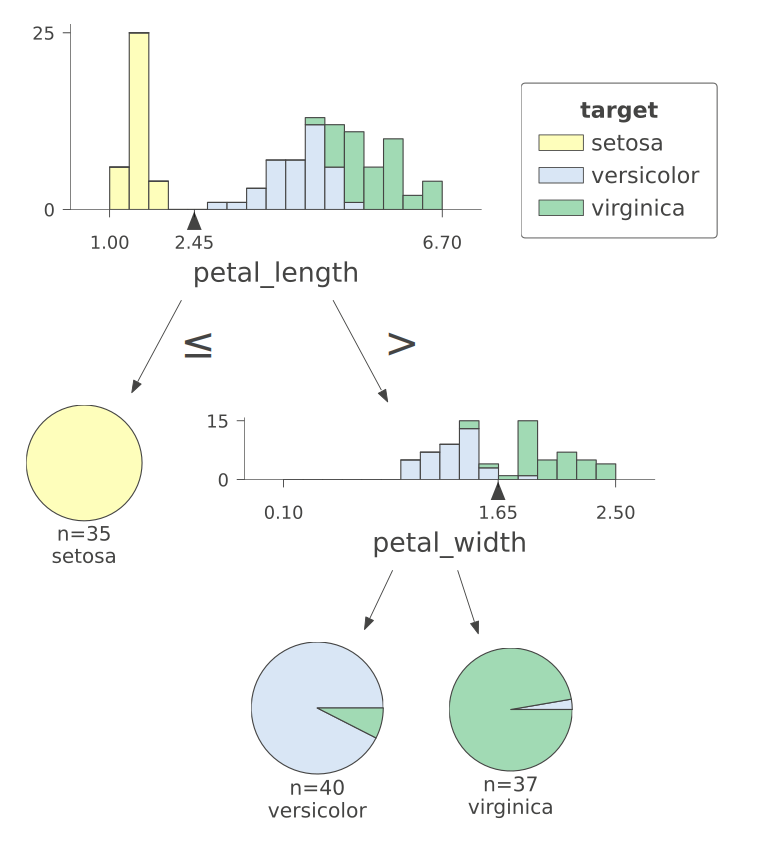

In [10]:
viz_model.view(fontname="DejaVu Sans", scale=3)

Les arbres de décision sont des modèles **« boîte blanche »**, ou encore **interprétables** : on peut facilement lire leurs décisions et expliquer *pourquoi* ils prédisent telle classe. Ce n'est pas le cas de la plupart des algorithmes de machine learning (réseaux de neurones, forêts aléatoires, SVM...), qu'on qualifie à l'inverse de **« boîtes noires »**.

> **🎯 À quoi sert cette interprétabilité en data science ?**
>
> C'est loin d'être un détail esthétique — dans beaucoup de contextes, l'interprétabilité est **obligatoire ou critique** :
>
> - **Santé** : un médecin qui utilise un modèle pour poser un diagnostic veut **comprendre pourquoi** le modèle recommande tel traitement. Une boîte noire qui dit *« proba(cancer) = 0,87 »* sans explication est inutilisable en pratique.
> - **Banque, assurance, crédit** : le **RGPD** et d'autres réglementations donnent aux clients le droit à une explication quand une décision automatisée les affecte (refus de crédit, tarif d'assurance...). Un arbre de décision permet de répondre : *« votre dossier a été refusé parce que votre ratio d'endettement > 42% et votre ancienneté < 2 ans »*.
> - **Debug et confiance** : quand un modèle se trompe, pouvoir lire ses règles permet de **comprendre l'erreur** et de l'améliorer. Avec une boîte noire, on subit.
> - **Détection de biais** : un arbre qui se met à segmenter sur une variable sensible (genre, origine, âge) le montre **noir sur blanc**. Plus difficile à repérer dans un réseau de neurones.
>
> **Autres avantages pratiques des arbres :**
> - Pas besoin de **normaliser** les features (contrairement à KNN, SVM, NN) — l'arbre découpe par seuils, donc l'échelle n'a pas d'importance.
> - Gère naturellement les **features numériques et catégorielles**.
> - Capture des relations **non linéaires** sans avoir à créer des features polynomiales.
>
> **Limite à connaître :** un arbre seul a tendance à **overfitter** (sur-apprendre). D'où l'intérêt des **forêts aléatoires** et du **gradient boosting** (XGBoost, LightGBM), qui combinent plein d'arbres pour gagner en performance... au prix d'une partie de l'interprétabilité.

### Estimation de la probabilité d'appartenance à une classe $k$

Un arbre ne prédit pas seulement *une classe*, il peut aussi donner une **probabilité** pour chaque classe. C'est utile quand on veut savoir à quel point le modèle est « sûr » de sa prédiction.

**Le principe :** quand une fleur arrive dans une feuille de l'arbre, on regarde **la composition des fleurs d'entraînement** qui sont tombées dans cette même feuille pendant l'apprentissage. La probabilité de chaque classe est simplement sa **proportion** dans la feuille.

**Exemple.** Supposons un iris avec des pétales de $4{,}8$ cm de longueur et $1{,}4$ cm de largeur. En descendant l'arbre, on arrive à la feuille de profondeur 2 à gauche, qui contient 41 fleurs d'entraînement réparties ainsi : `[0, 38, 3]`. Les probabilités estimées sont donc :

- $p_{\text{setosa}} = \frac{0}{41} = 0$
- $p_{\text{versicolor}} = \frac{38}{41} \approx 0{,}93$
- $p_{\text{virginica}} = \frac{3}{41} \approx 0{,}07$

**Remarque importante :** toutes les fleurs qui tombent dans la même feuille auront exactement les mêmes probabilités prédites. L'arbre ne « raffine » pas au sein d'une feuille. C'est une des raisons pour lesquelles les probabilités d'un arbre seul sont souvent grossières — les ensembles (random forest, gradient boosting) les lissent beaucoup mieux.

In [11]:
np.round(tree_clf.predict_proba([[4.8, 1.4]]), 2)

array([[0.  , 0.92, 0.08]])

## La phase d'apprentissage

**L'algorithme CART** (Classification And Regression Tree) est la méthode utilisée par scikit-learn pour construire l'arbre. Son fonctionnement est d'une simplicité déconcertante :

1. À chaque nœud, l'algorithme **essaie toutes les features et tous les seuils possibles**.
2. Il garde le couple (feature $k$, seuil $t_k$) qui **minimise une fonction de coût** — autrement dit, celui qui produit les deux sous-groupes les plus « purs » possible.
3. Il recommence récursivement sur chaque sous-groupe.
4. Il s'arrête quand un critère d'arrêt est atteint (profondeur max, nœud pur, trop peu d'échantillons...).

### La fonction de coût

$
\Large{
J(k, t_k) = \frac{m_{\mathit{left}}}{m} G_{\mathit{left}} + \frac{m_{\mathit{right}}}{m} G_{\mathit{right}}
}
$

**Décodage :**
- $k$ : la feature candidate (ex : `petal_length`).
- $t_k$ : le seuil candidat (ex : $2{,}35$).
- $m$ : le nombre total d'échantillons dans le nœud courant.
- $m_{\mathit{left}}$ et $m_{\mathit{right}}$ : combien d'échantillons tombent à gauche (ceux qui vérifient $X_k \le t_k$) et à droite après le split.
- $G_{\mathit{left}}$, $G_{\mathit{right}}$ : le Gini (impureté) de chaque sous-groupe.
- Les rapports $\frac{m_{\mathit{left}}}{m}$ et $\frac{m_{\mathit{right}}}{m}$ sont des **pondérations** : un sous-groupe qui ne contient que 2 fleurs pèse moins qu'un qui en contient 100.

**En langage courant :** le coût est la **moyenne pondérée des impuretés** des deux sous-groupes issus du split. On cherche le split qui **minimise l'impureté moyenne** des enfants — c'est-à-dire celui qui rend les classes le plus séparées possible.

### Critère d'arrêt et hyperparamètres

L'algorithme s'arrête lorsque la profondeur maximale `max_depth` est atteinte (ici fixée à 2). `max_depth` est un exemple d'**hyperparamètre** — un réglage que l'utilisateur choisit *avant* l'entraînement et qui contrôle le comportement de l'algorithme. D'autres hyperparamètres utiles :

- `min_samples_split` : nombre minimum d'échantillons pour autoriser un split ;
- `min_samples_leaf` : nombre minimum d'échantillons dans une feuille ;
- `max_leaf_nodes` : nombre maximum de feuilles.

**Tous servent à la même chose : contrôler la complexité de l'arbre et éviter l'overfitting.** Un arbre trop profond apprend « par cœur » ses données d'entraînement et généralise mal. On les ajuste typiquement par validation croisée (voir un prochain notebook).

In [12]:
tree_clf.score(X_train, y_train)

0.9642857142857143

In [13]:
tree_clf.score(X_test, y_test)

0.9473684210526315

## Complexité de l'algorithme

*Notations :* $m$ = nombre d'échantillons d'entraînement, $n$ = nombre de features.

### Décision (prédiction)

Pour classer un nouvel échantillon, il suffit de descendre l'arbre de la racine jusqu'à une feuille en répondant à une question à chaque niveau. Comme les arbres construits par CART sont généralement à peu près **équilibrés**, leur profondeur est en $\log_2(m)$. La décision est donc en $\mathcal{O}(\log_2(m))$, **quel que soit le nombre de features**.

**C'est extrêmement rapide :** 1 million d'échantillons → environ 20 questions à poser pour classer un nouvel exemple. C'est ce qui rend les arbres attractifs pour les systèmes qui doivent prédire en temps réel.

### Apprentissage

À chaque nœud, l'algorithme doit comparer **toutes les features** et **tous les seuils candidats**, pour chaque donnée. Sur un arbre équilibré, cela donne une complexité totale en $\mathcal{O}(n \times m \log_2(m))$.

**En pratique :** l'entraînement est rapide sur des jeux de taille modeste (< 1M lignes). Sur de gros jeux, on préférera des implémentations optimisées comme **LightGBM** ou **XGBoost**, qui utilisent des histogrammes pour ne pas avoir à trier les valeurs continues à chaque split.

## Régression

Jusqu'ici, l'arbre prédisait une **classe** (setosa / versicolor / virginica). On peut aussi utiliser exactement la même structure d'arbre pour prédire un **nombre continu** — par exemple un prix, une température, une note.

> **Exemple de problèmes de régression :**
> - Prédire le **prix d'une maison** à partir de ses caractéristiques.
> - Prédire la **progression d'une maladie** à partir de mesures biologiques (c'est le dataset `diabetes` qu'on va utiliser ci-dessous).
> - Prédire une **température** en fonction de l'heure, de la saison, de la météo...

**Deux différences avec la classification :**

1. **Ce que contiennent les feuilles.** En classification, chaque feuille prédit une *classe*. En régression, chaque feuille prédit un *nombre* — en pratique, la **moyenne** des $y$ d'entraînement tombés dans cette feuille.

2. **Le critère de split.** On ne peut plus utiliser le Gini (qui parle de classes). À la place, on utilise la **MSE** (*Mean Squared Error*), c'est-à-dire la moyenne des carrés des écarts à la moyenne dans chaque sous-groupe. L'algorithme cherche le split qui minimise cette MSE pondérée — autrement dit, qui regroupe dans chaque sous-groupe des valeurs $y$ **les plus proches possibles les unes des autres**.

Le reste (descente dans l'arbre, hyperparamètres, complexité) fonctionne exactement pareil.

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

In [15]:
diabetes = load_diabetes()

In [16]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=2
)

In [18]:
X_train

array([[-0.00188202, -0.04464164, -0.06979687, ..., -0.03949338,
        -0.06291688,  0.04034337],
       [-0.00914709, -0.04464164,  0.01103904, ..., -0.03949338,
         0.01703607, -0.0052198 ],
       [ 0.02354575,  0.05068012, -0.02021751, ..., -0.03949338,
        -0.09643495, -0.01764613],
       ...,
       [ 0.06350368,  0.05068012, -0.00405033, ..., -0.00259226,
         0.08449153, -0.01764613],
       [-0.05273755,  0.05068012, -0.01806189, ...,  0.1081111 ,
         0.03606033, -0.04249877],
       [ 0.00175052,  0.05068012,  0.05954058, ...,  0.1081111 ,
         0.06898589,  0.12732762]])

In [19]:
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=2)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

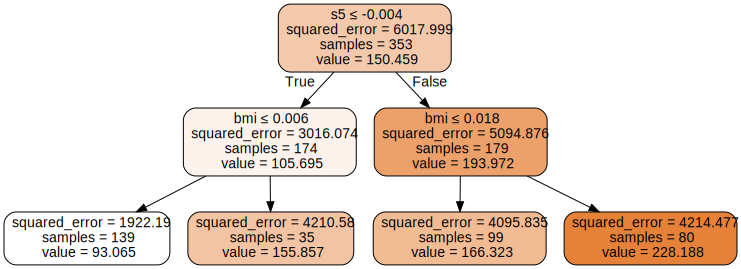

In [20]:
dot_data = export_graphviz(tree_reg, out_file=None, 
                           feature_names=diabetes.feature_names,  
                           filled=True, rounded=True,  
                           special_characters=True)
Source(dot_data)

In [21]:
viz_model = dtreeviz.model(tree_reg, X_train=X_train, y_train=y_train,
               feature_names=diabetes.feature_names,
               target_name="target")


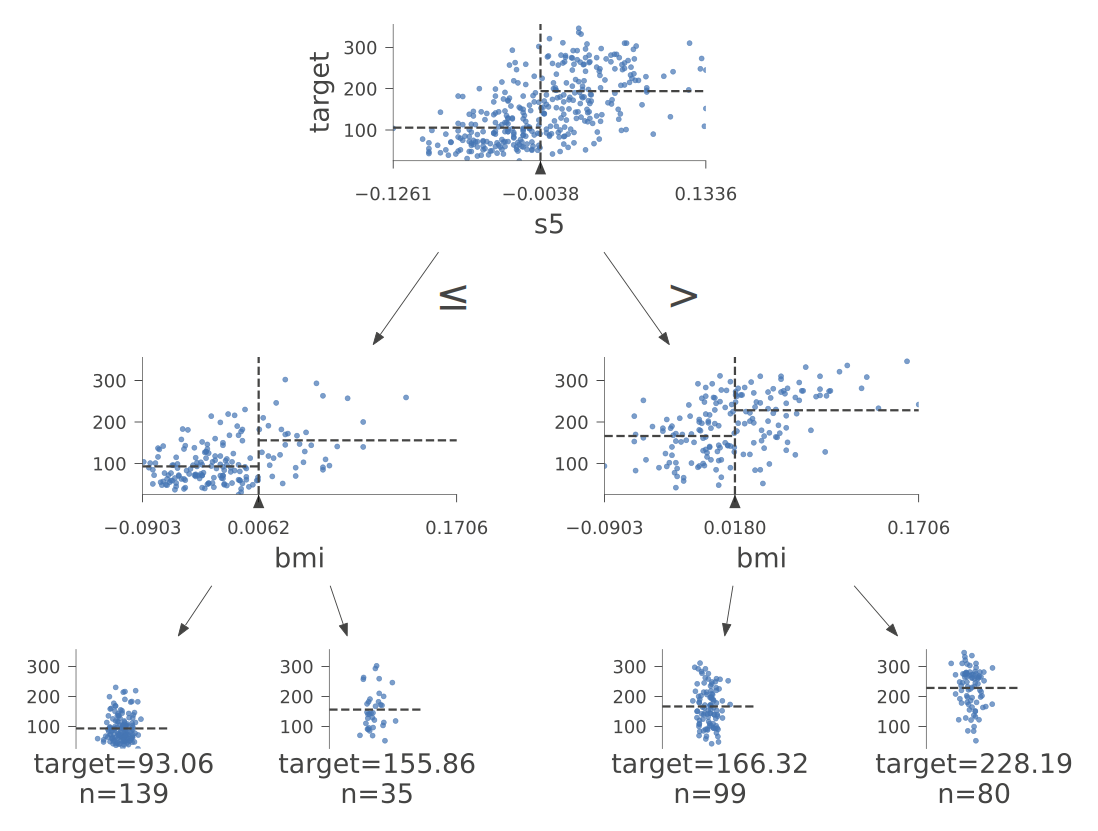

In [22]:
viz_model.view(fontname="DejaVu Sans", scale=3)

L'arbre prédit une valeur (un nombre), et non plus une classe. On peut évaluer sa qualité avec des métriques de régression classiques comme la **MAE** (Mean Absolute Error) : *« en moyenne, de combien se trompe-t-on, dans les mêmes unités que la cible ? »*.

In [23]:
y_pred = tree_reg.predict(X_test)
mean_absolute_error(y_test, y_pred)

np.float64(47.51175956214455)

In [24]:
y_test

array([ 73., 233.,  97., 111., 277., 341.,  64.,  68.,  65., 178., 142.,
        77., 244., 115., 258.,  87., 220.,  86.,  74., 132., 136., 220.,
        91., 235., 148., 317., 131.,  84.,  65., 217., 306.,  79., 158.,
        54., 123., 174., 237., 212., 179., 281., 187., 200.,  68., 163.,
       141., 202., 178., 242.,  47., 131., 243., 142., 200.,  89., 232.,
        55., 253., 128., 104., 184., 110., 198.,  81., 195., 150.,  63.,
       151., 233., 178.,  84., 237., 109., 131., 252., 200., 160., 200.,
        51., 111.,  77., 201.,  88.,  78., 243., 268.,  55., 270., 288.,
        91.])

In [25]:
y_pred

array([166.32323232, 228.1875    ,  93.0647482 ,  93.0647482 ,
       228.1875    , 228.1875    ,  93.0647482 ,  93.0647482 ,
        93.0647482 , 228.1875    , 166.32323232,  93.0647482 ,
       155.85714286, 166.32323232, 228.1875    ,  93.0647482 ,
       228.1875    , 166.32323232, 166.32323232,  93.0647482 ,
       155.85714286, 228.1875    , 166.32323232, 166.32323232,
        93.0647482 , 228.1875    , 155.85714286,  93.0647482 ,
        93.0647482 , 228.1875    , 228.1875    ,  93.0647482 ,
        93.0647482 ,  93.0647482 , 166.32323232, 166.32323232,
       228.1875    , 166.32323232,  93.0647482 , 166.32323232,
       155.85714286,  93.0647482 , 228.1875    , 166.32323232,
       228.1875    , 166.32323232, 155.85714286, 228.1875    ,
        93.0647482 , 166.32323232, 228.1875    , 155.85714286,
        93.0647482 ,  93.0647482 , 228.1875    ,  93.0647482 ,
        93.0647482 ,  93.0647482 ,  93.0647482 , 155.85714286,
       166.32323232, 155.85714286,  93.0647482 , 228.18

## 🎯 Pour résumer — les arbres de décision en data science

**Quand utiliser un arbre de décision seul ?**
- Quand **l'interprétabilité** est cruciale (santé, finance, juridique, audit).
- Comme **baseline rapide** pour comprendre un problème, voir quelles features sont importantes et visualiser les règles que les données « contiennent ».
- Quand on veut un modèle **sans préparation** (pas besoin de normaliser, peu sensible aux outliers, gère les types mixtes).

**Quand passer à autre chose ?**
- Un arbre seul **overfitte facilement** et plafonne vite en performance. Pour des problèmes prédictifs réels, on utilise presque toujours des **ensembles d'arbres** :
  - **Random Forest** : on entraîne plein d'arbres sur des sous-échantillons différents et on vote / moyenne. Simple et robuste.
  - **Gradient Boosting** (XGBoost, LightGBM, CatBoost) : chaque arbre corrige les erreurs du précédent. **État de l'art** sur la plupart des problèmes de données tabulaires, et souvent vainqueurs des compétitions Kaggle.
- Si on a des **images, du texte ou des séries temporelles complexes**, les réseaux de neurones sont généralement plus adaptés.

**À retenir :** l'arbre de décision est à la fois **le modèle le plus simple à expliquer** et la **brique de base** des modèles tabulaires les plus performants du marché. Bien comprendre comment il marche, c'est comprendre les fondations de tout l'écosystème boosting/forest qui domine le ML tabulaire aujourd'hui.